# Automatización del procesamiento de archivos MAGPHYS para la construcción de SEDs
MAGPHYS genera un conjunto de archivos de salida que incluye un archivo `.fit` y un archivo `.sed` para cada galaxia analizada, además de un archivo global `observations.dat` que reúne las observaciones de todos los objetos. Cuando se trabaja con decenas o cientos de galaxias, abrir cada archivo manualmente y construir los gráficos resulta repetitivo y propenso a errores.

En este proyecto se automatiza la lectura de dichos archivos para generar de manera sistemática las distribuciones de energía espectral (SED) y extraer algunos parámetros físicos de las galaxias.

### Objetivo
Automatizar la lectura de los archivos de salida de MAGPHYS para:
- identificar las galaxias disponibles
- leer archivos `.sed`
- leer archivos `.fit`
- extraer parámetros físicos
- generar automáticamente un gráfico por galaxia
- guardar cada figura


### Configuración

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import pandas as pd
import matplotlib.ticker as ticker
from matplotlib.ticker import FormatStrFormatter
import os

En esta sección se define la carpeta donde se encuentran los archivos de entrada y se crea automáticamente un directorio para almacenar las figuras generadas.

In [2]:
input_dir = "data"          # Dirección de la carpeta con los archivos de entrada.
output_dir = "plots"        # Carpeta en donde se almacenaran los graficos resultantes.
os.makedirs(output_dir, exist_ok=True)

## Funciones

### Identificación de galaxias

La siguiente función obtiene los nombres de las galaxias disponibles a partir del archivo `observations.dat`.

In [3]:
def get_object_ids(lines):
    """
    Extract object IDs from an observations file.

    Parameters
    -----------
    lines   :   list of str
        Lines read from ``observations.dat`` using ``readlines()``.
        The first line is assumed to be a header and is ignored.
    
    Returns
    --------
    list of str
        List containing the ID of each object.
    """
    
    parsed_lines    = [i.strip().split() for i in lines[1:]]
    names           = [row[0] for row in parsed_lines]
    
    return names

### Lectura de archivos `.sed`

Se extrae la distribución espectral de energía (SED), obteniendo la longitud de onda y las luminosidades atenuada y no atenuada.

In [4]:
def read_sed(lines):
    """
    Read the spectral energy distribution (SED) from a MAGPHYS ``.sed`` file.

    Parameters
    ----------
    lines : list of str
        Lines read from a ``.sed`` file using ``readlines()``.
        The function assumes that the first 10 lines correspond to the file
        header and ignores them. The last line is also ignored.

    Returns
    -------
    wavelength : list of float
        Wavelength values.

    attenuated_luminosity : list of float
        Attenuated luminosity values.

    unattenuated_luminosity : list of float
        Unattenuated luminosity values.
    """

    sed_rows    = [i.strip().split() for i in lines[10:-1]]
    df          = pd.DataFrame(sed_rows)
    df.columns  = ['lambda', 'atten', 'unatten']

    wavelength               = [float(i) for i in df['lambda']]
    attenuated_luminosity   = [float(i) for i in df['atten']]
    unattenuated_luminosity = [float(i) for i in df['unatten']]
    
    return wavelength, attenuated_luminosity, unattenuated_luminosity

### Lectura de archivos `.fit`

Se extraen los flujos observados y los parámetros físicos estimados por MAGPHYS para cada galaxia.

In [5]:
def read_fit(lines):
    """
    Read observational fluxes, uncertainties, and selected physical parameters
    from a MAGPHYS ``.fit`` file.

    Parameters
    ----------
    lines : list of str
        Lines read from a ``.fit`` file using ``readlines()``.
        The function assumes the MAGPHYS file structure, where:
        - line 2 contains the observed fluxes,
        - line 3 contains the corresponding flux uncertainties,
        - line 10 contains the fitted physical parameters.

    Returns
    -------
    fit_flux : numpy.ndarray
        Observed fluxes.

    fit_error : numpy.ndarray
        Uncertainties associated with the observed fluxes.

    mass : float
        Stellar mass.

    sfr : float
        Star formation rate.

    dust : float
        Dust luminosity.

    tvism : float
        V-band optical depth of the interstellar medium.
    """
    flux_rows       = [i.strip().split() for i in lines[2:4]]
    parameter_row   = [i.strip().split() for i in lines[10:11]]
    
    param_mass  = 5
    param_dust  = 6
    param_tvism = 13
    param_sfr   = 15

    mass    = float(parameter_row[0][param_mass])
    sfr     = float(parameter_row[0][param_sfr])
    dust    = float(parameter_row[0][param_dust])
    tvism   = float(parameter_row[0][param_tvism])
    
    fit_flux_str = flux_rows[0]
    fit_error_str = flux_rows[1]

    fit_flux_list   = [float(i) for i in fit_flux_str]
    fit_error_list  = [float(i) for i in fit_error_str]
    
    fit_flux    = np.array(fit_flux_list)
    fit_error   = np.array(fit_error_list)
    
    return fit_flux, fit_error, mass, sfr, dust, tvism


### Lectura de histogramas de probabilidad

Se leen las distribuciones de probabilidad de los parámetros físicos generadas por MAGPHYS y se almacenan en un diccionario para su posterior visualización.

In [6]:
def load_histograms(input_dir,object_id):
    """
    Read the parameter probability distributions stored in a MAGPHYS ``.fit`` file.

    Parameters
    ----------
    input_dir : str
        Directory containing the MAGPHYS input files.

    object_id : str
        Identifier of the object. The function reads the file
        ``<input_dir>/<object_id>.fit``.

    Returns
    -------
    dict
        Dictionary mapping each parameter name to a list of
        ``(bin_center, probability)`` tuples representing its probability
        distribution.
    """
    file_path = os.path.join(input_dir, f"{object_id}.fit")

    histogram_data = {}
    current_param = None
    parameters_names = []

    with open(file_path, 'r') as file:
        for line in file:
            line = line.strip()

            if line.startswith('# ...'):
                param_name = line[5:].strip()
                if param_name not in parameters_names:
                    parameters_names.append(param_name[:-4])    # Parameter names in the .fit file end with " ...", which is removed.
                    current_param = param_name[:-4]
                    histogram_data[current_param] = []

            if (current_param != None) and not line.startswith('#'):
                parts = line.split()
                if len(parts) == 2:
                    bin_center, probability = float(parts[0]), float(parts[1])
                    histogram_data[current_param].append((bin_center, probability))
        
    return histogram_data

### Generación de gráficos

Se representa la distribución espectral de energía (SED) junto con las distribuciones de probabilidad de los principales parámetros físicos y se guarda la figura en formato PNG.

In [7]:
def plot_sed(wavelengths, attenuated_luminosity, unattenuated_luminosity,id_galaxy,output_dir,histograms,mass,sfr,dust,tvism):
    """
    Generate and save the spectral energy distribution (SED) plot together
    with the probability distributions of the fitted physical parameters.

    Parameters
    ----------
    wavelengths : array-like
        Logarithmic wavelength values in Angstrom.

    attenuated_luminosity : array-like
        Logarithmic attenuated luminosities.

    unattenuated_luminosity : array-like
        Logarithmic unattenuated luminosities.

    id_galaxy : str
        Galaxy identifier used in the plot title and output filename.

    output_dir : str
        Directory where the figure will be saved.

    histograms : dict
        Dictionary containing the parameter probability distributions.

    mass : float
        Stellar mass.

    sfr : float
        Star formation rate.

    dust : float
        Dust luminosity.

    tau_v_ism : float
        V-band optical depth of the diffuse interstellar medium.

    Returns
    -------
    None

    """    
    wavelength_linear   = 10**np.array(wavelengths)
    attenuated_linear   = 10**np.array(attenuated_luminosity)
    unattenuated_linear = 10**np.array(unattenuated_luminosity)

    y_atten = np.log10(wavelength_linear*attenuated_linear)
    y_unatten = np.log10(wavelength_linear*unattenuated_linear)
    wavelength  = wavelength_linear/1e4                            # Conversion from Angstrom to micrometer
    
       
    fig = plt.figure(figsize=(7, 6))
    gs = gridspec.GridSpec(2, 4, height_ratios=[2, 1])

    sed_ylim    = (6,12)
    mass_xlim   = (10.5,11.5)
    sfr_xlim    = (1, 1.6)
    dust_xlim   = (11, 12.1)
    tau_xlim    = (0, 1)

    ax_main = fig.add_subplot(gs[0, :])
    ax_main.plot(wavelength,y_atten,color='black',linewidth=0.9)
    ax_main.plot(wavelength,y_unatten,color='turquoise',linewidth=0.7)
    ax_main.set_xscale('log')
    ax_main.set_ylim(sed_ylim)
    ax_main.text(900, 7.5, 'ID: '+str(id_galaxy), ha='right', va='bottom', fontsize=10)
    ax_main.tick_params(axis='x', which='both',direction='in')
    ax_main.tick_params(axis='y', which='both',direction='in')
    ax_main.minorticks_on()
    ax_main.set_xlabel('$\\lambda$/$\\mu$m [observed - frame]',fontsize=12)
    ax_main.set_ylabel('log($\\lambda L_{\\lambda/ L_{sun}}$)',fontsize=12)


    # Lower graphs (row 2, column 1)
    x_list1, y_list1 = zip(*histograms['M(stars)'])
    width1 = abs(x_list1[0] - x_list1[1])
    median1 = np.log10(mass)

    ax1 = fig.add_subplot(gs[1, 0])
    ax1.bar(x_list1, y_list1, width=width1, edgecolor='gray', fill=True, facecolor='gray')
    ax1.axvline(median1, color='midnightblue', linewidth=3)
    ax1.set_xlim(mass_xlim)
    ax1.set_xlabel('log(M$_*$)',fontsize=12)
    
    x_list2, y_list2 = zip(*histograms['SFR_0.1Gyr'])
    width2 = abs(x_list2[0] - x_list2[1])
    median2 = np.log10(sfr)

    ax2 = fig.add_subplot(gs[1, 1])
    ax2.bar(x_list2, y_list2, width=width2, edgecolor='gray', fill=True, facecolor='gray')
    ax2.axvline(median2, color='midnightblue', linewidth=3)
    ax2.set_xlim(sfr_xlim)
    ax2.set_xlabel('log(SFR)',fontsize=12)
    
    x_list3, y_list3 = zip(*histograms['Ldust'])
    width3 = abs(x_list3[0] - x_list3[1])
    median3 = np.log10(dust)

    ax3 = fig.add_subplot(gs[1, 2])
    ax3.bar(x_list3, y_list3, width=width3, edgecolor='gray', fill=True, facecolor='gray')
    ax3.axvline(median3, color='midnightblue', linewidth=3)
    ax3.set_xlim(dust_xlim)
    ax3.set_xlabel('log(L$_{dust}$)',fontsize=12)
    
    x_list4, y_list4 = zip(*histograms['tau_V^IS'])
    width4 = abs(x_list4[0] - x_list4[1])
    median4 = tvism

    ax4 = fig.add_subplot(gs[1, 3])
    ax4.bar(x_list4, y_list4, width=width4, edgecolor='gray', fill=True, facecolor='gray')
    ax4.axvline(median4, color='midnightblue', linewidth=3)
    ax4.set_xlim(tau_xlim)
    ax4.set_xlabel('$\\mu\\tau_V$',fontsize=12)
    
    ax1.set_yscale('log')
    ax2.set_yscale('log')
    ax3.set_yscale('log')
    ax4.set_yscale('log')

    ax1.set_yticks(ticks = [0.01, 0.1, 1], labels=[0.01, 0.10, 1.00])
    ax1.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))
    
    ax2.set_yticks(ticks = [0.01, 0.1, 1], labels=[])
    ax3.set_yticks(ticks = [0.01, 0.1, 1], labels=[])
    ax4.set_yticks(ticks = [0.01, 0.1, 1], labels=[])
    
    ax1.set_xticks(ticks = [10.5, 11, 11.5], labels=[10.5, 11, 11.5])
    ax2.set_xticks(ticks = [1, 1.3, 1.6], labels=[1, 1.3, 1.6])
    ax3.set_xticks(ticks = [11, 11.5, 12], labels=[11, 11.5, 12])
    ax4.set_xticks(ticks = [0, 0.5, 1], labels=[0, 0.5, 1])

    
    for ax in (ax1, ax2, ax3, ax4):
        ax.set_ylim(0.01, 1.009)
        ax.tick_params(axis='y', which='minor', direction='in', length=2, width=0.7, left = True, right = True)
        ax.tick_params(axis='y', which='major', direction='in', length=4, width=0.7, left = True, right = True)
    
    ax1.set_ylabel('Probability')

    output_path = os.path.join(output_dir,f"{id_galaxy}.png")
    
    plt.tight_layout()
    plt.savefig(output_path)
    plt.show()
    
    
    return

### Procesamiento

In [8]:
observations        = open(os.path.join(input_dir,'observations.dat')).readlines()
galaxy_id_list      = get_object_ids(observations)
mass_sfr_catalog    = np.zeros([1,2])

C:\Users\sofis\AppData\Local\Temp\ipykernel_8060\1671681314.py:48: RuntimeWarning: divide by zero encountered in log10
  y_unatten = np.log10(wavelength_linear*unattenuated_linear)


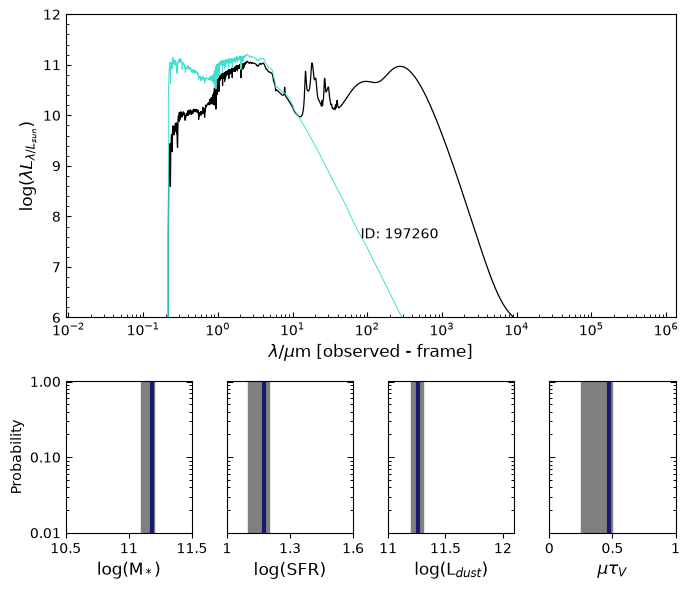

C:\Users\sofis\AppData\Local\Temp\ipykernel_8060\1671681314.py:48: RuntimeWarning: divide by zero encountered in log10
  y_unatten = np.log10(wavelength_linear*unattenuated_linear)


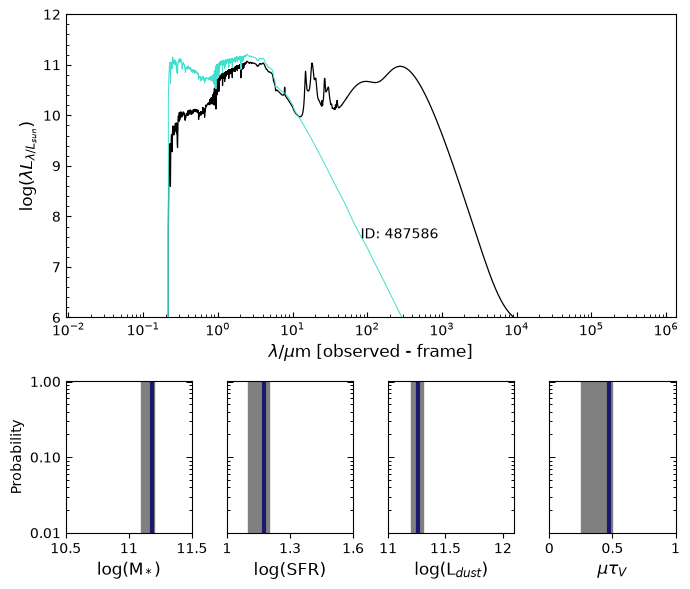

C:\Users\sofis\AppData\Local\Temp\ipykernel_8060\1671681314.py:48: RuntimeWarning: divide by zero encountered in log10
  y_unatten = np.log10(wavelength_linear*unattenuated_linear)


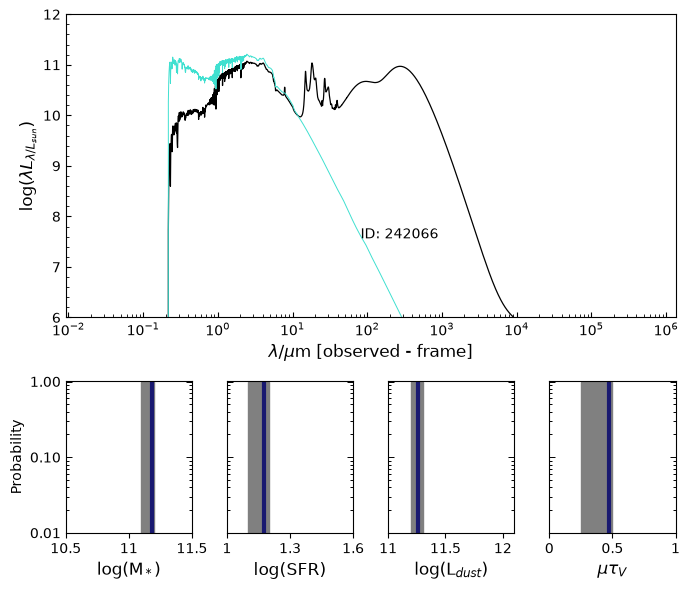

In [9]:
for galaxy_id in galaxy_id_list:
    data_sed    = open(os.path.join(input_dir,galaxy_id+'.sed')).readlines()
    data_fit    = open(os.path.join(input_dir,galaxy_id+'.fit')).readlines()
     
    lambda_A, attenuated_luminosity, unattenuated_luminosity    = read_sed(data_sed)
    fluxfit, errorfit, mass, sfr, dust, tvismm                  = read_fit(data_fit)
    histogram                                                   = load_histograms(input_dir,galaxy_id)
        
    mass_sfr            = np.asarray([mass,sfr])
    mass_sfr_catalog    = np.vstack([mass_sfr_catalog,mass_sfr])

    graph = plot_sed(lambda_A, attenuated_luminosity, unattenuated_luminosity,galaxy_id,output_dir,histogram,mass,sfr,dust,tvismm)


np.savetxt('mass_sfr.dat',mass_sfr_catalog)     # If you want, you can add a header to the file later #mass sfr

### Resultado de la automatización

La ejecución del notebook permitió procesar automáticamente todos los archivos disponibles en el directorio de entrada. Para cada galaxia se leyeron los archivos `.fit` y `.sed`, se extrajeron los parámetros físicos correspondientes y se generó una figura con su distribución de energía espectral (SED). Las figuras fueron almacenadas automáticamente en el directorio de salida.

En este repositorio se incluyen tres copias de los mismos archivos de entrada con el único propósito de demostrar que el flujo de trabajo procesa múltiples objetos de forma automática. En un escenario real, el mismo procedimiento puede aplicarse a cualquier conjunto de galaxias generado por MAGPHYS sin necesidad de modificar el código.

Realizado por: Sofia Saavedra